**LSB-replacement в grayscale-изображения 256×256**


**Условия:**

- Размер изображения: 256×256
- Количество пикселей: 65536
- В каждый пиксель внедряется 1 бит
- Максимальный размер сообщения: 65536 бит = 8192 байт
- Исходный датасет:
/content/drive/MyDrive/FQW/grayscale_dataset
- Новый датасет (стего):
/content/drive/MyDrive/FQW/grayscale_dataset_LSB

In [16]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Функции LSB-встраивания

Реализуем классический LSB-replacement:

$pixelnew​=(pixel&0xFE)∣bit$

In [17]:
import os
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Пути к датасетам
INPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset/'
OUTPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset_LSB/'

# Создаем выходную папку
os.makedirs(OUTPUT_DIR, exist_ok=True)

def text_to_binary(text):
    """Преобразует текст в бинарную строку"""
    return ''.join(format(ord(char), '08b') for char in text)

def embed_lsb_grayscale(image_path, output_path, message):
    """
    Внедряет сообщение в младшие биты grayscale изображения

    Args:
        image_path: путь к исходному изображению
        output_path: путь для сохранения
        message: скрываемое сообщение (строка)
    """
    # Открываем изображение
    img = Image.open(image_path).convert('L')  # Grayscale
    pixels = np.array(img)

    # Преобразуем сообщение в бинарный вид
    binary_message = text_to_binary(message)

    # Добавляем маркер конца сообщения (32 нуля)
    binary_message += '0' * 32

    # Проверяем вместимость
    max_bits = pixels.size  # 65536 бит для 256x256
    if len(binary_message) > max_bits:
        raise ValueError(f"Сообщение слишком длинное! Максимум {max_bits//8} символов")

    # Внедряем в LSB каждого пикселя
    pixel_idx = 0
    for bit in binary_message:
        row = pixel_idx // 256
        col = pixel_idx % 256
        # Очищаем младший бит и устанавливаем новый
        pixels[row, col] = (pixels[row, col] & 0xFE) | int(bit)
        pixel_idx += 1

    # Сохраняем результат
    result_img = Image.fromarray(pixels, mode='L')
    result_img.save(output_path)

    return len(message)

def extract_lsb_grayscale(image_path, max_chars=1000):
    """
    Извлекает скрытое сообщение из изображения

    Args:
        image_path: путь к изображению с LSB
        max_chars: максимальное количество символов для извлечения
    """
    img = Image.open(image_path).convert('L')
    pixels = np.array(img)

    # Извлекаем младшие биты
    binary_data = ''
    for row in range(pixels.shape[0]):
        for col in range(pixels.shape[1]):
            binary_data += str(pixels[row, col] & 1)

    # Преобразуем в текст
    message = ''
    for i in range(0, min(len(binary_data), max_chars * 8), 8):
        byte = binary_data[i:i+8]
        if len(byte) == 8:
            char = chr(int(byte, 2))
            if char == '\x00':  # Маркер конца
                break
            message += char

    return message

In [18]:
# Основная обработка датасета

# Скрываемое сообщение
SECRET_MESSAGE = "STEGANO_HIDDEN_DATA_2026"

print(f"Начало обработки датасета...")
print(f"Входная папка: {INPUT_DIR}")
print(f"Выходная папка: {OUTPUT_DIR}")
print(f"Скрываемое сообщение: {SECRET_MESSAGE}")
print(f"Длина сообщения: {len(SECRET_MESSAGE)} символов ({len(SECRET_MESSAGE)*8} бит)")
print("-" * 50)

# Получаем список всех изображений
image_files = sorted([f for f in os.listdir(INPUT_DIR)
                      if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

print(f"Найдено изображений: {len(image_files)}")

# Обрабатываем каждое изображение
processed = 0
for img_file in image_files:
    input_path = os.path.join(INPUT_DIR, img_file)
    output_filename = img_file.replace('.png', '_lsb.png').replace('.jpg', '_lsb.jpg')
    output_path = os.path.join(OUTPUT_DIR, output_filename)

    try:
        embed_lsb_grayscale(input_path, output_path, SECRET_MESSAGE)
        processed += 1
        if processed % 50 == 0:
            print(f"Обработано: {processed}/{len(image_files)}")
    except Exception as e:
        print(f"Ошибка обработки {img_file}: {e}")

print("-" * 50)
print(f"Обработано изображений: {processed}/{len(image_files)}")
print(f"Датасет сохранён в: {OUTPUT_DIR}")

Начало обработки датасета...
Входная папка: /content/drive/MyDrive/FQW/grayscale_dataset/
Выходная папка: /content/drive/MyDrive/FQW/grayscale_dataset_LSB/
Скрываемое сообщение: STEGANO_HIDDEN_DATA_2026
Длина сообщения: 24 символов (192 бит)
--------------------------------------------------
Найдено изображений: 256


/tmp/ipykernel_13059/2482497454.py:52: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  result_img = Image.fromarray(pixels, mode='L')


Обработано: 50/256
Обработано: 100/256
Обработано: 150/256
Обработано: 200/256
Обработано: 250/256
--------------------------------------------------
Обработано изображений: 256/256
Датасет сохранён в: /content/drive/MyDrive/FQW/grayscale_dataset_LSB/


**ПРОВЕРКА ИЗМЕНЕНИЯ ПИКСЕЛЕЙ**

In [19]:
# Пути
INPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset'
OUTPUT_DIR = '/content/drive/MyDrive/FQW/grayscale_dataset_LSB'
SECRET_MESSAGE = "STEGANO_HIDDEN_DATA_2026"

#  ПРОВЕРКА ИЗМЕНЕНИЯ ПИКСЕЛЕЙ


def analyze_pixel_changes(original_path, lsb_path):
    """
    Анализ изменения пикселей между оригиналом и LSB-изображением
    """
    img_orig = np.array(Image.open(original_path).convert('L'))
    img_lsb = np.array(Image.open(lsb_path).convert('L'))

    # Разница между изображениями
    diff = img_orig.astype(int) - img_lsb.astype(int)

    # Статистика изменений
    changed_pixels = np.sum(diff != 0)
    total_pixels = img_orig.size
    change_percentage = (changed_pixels / total_pixels) * 100

    # Какие биты изменились
    unique_changes = np.unique(diff)

    # LSB биты оригинала и модифицированного
    lsb_orig = img_orig & 1
    lsb_lsb = img_lsb & 1

    return {
        'total_pixels': total_pixels,
        'changed_pixels': changed_pixels,
        'change_percentage': change_percentage,
        'unique_changes': unique_changes,
        'lsb_orig_sum': np.sum(lsb_orig),
        'lsb_lsb_sum': np.sum(lsb_lsb),
        'diff': diff
    }

def visualize_pixel_changes(original_path, lsb_path, sample_size=50):
    """
    Визуализация изменений пикселей
    """
    img_orig = np.array(Image.open(original_path).convert('L'))
    img_lsb = np.array(Image.open(lsb_path).convert('L'))

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Оригинальное изображение
    axes[0, 0].imshow(img_orig, cmap='gray')
    axes[0, 0].set_title('Оригинал')
    axes[0, 0].axis('off')

    # LSB изображение
    axes[0, 1].imshow(img_lsb, cmap='gray')
    axes[0, 1].set_title('С внедрённым LSB')
    axes[0, 1].axis('off')

    # Разница (усилена для видимости)
    diff = np.abs(img_orig.astype(int) - img_lsb.astype(int)) * 50
    axes[0, 2].imshow(diff, cmap='hot')
    axes[0, 2].set_title('Разница (усилена 50x)')
    axes[0, 2].axis('off')

    # Гистограмма оригинала
    axes[1, 0].hist(img_orig.flatten(), bins=256, range=(0, 256), color='gray', alpha=0.7)
    axes[1, 0].set_title('Гистограмма оригинала')
    axes[1, 0].set_xlabel('Яркость')
    axes[1, 0].set_ylabel('Количество пикселей')

    # Гистограмма LSB
    axes[1, 1].hist(img_lsb.flatten(), bins=256, range=(0, 256), color='blue', alpha=0.7)
    axes[1, 1].set_title('Гистограмма LSB')
    axes[1, 1].set_xlabel('Яркость')
    axes[1, 1].set_ylabel('Количество пикселей')

    # Распределение LSB битов
    lsb_bits_orig = img_orig & 1
    lsb_bits_lsb = img_lsb & 1
    axes[1, 2].bar(['0', '1'], [np.sum(lsb_bits_orig == 0), np.sum(lsb_bits_orig == 1)],
                   alpha=0.5, label='Оригинал', color='gray')
    axes[1, 2].bar(['0.1', '1.1'], [np.sum(lsb_bits_lsb == 0), np.sum(lsb_bits_lsb == 1)],
                   alpha=0.5, label='LSB', color='blue')
    axes[1, 2].set_title('Распределение LSB битов')
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

    return img_orig, img_lsb

In [20]:
# ИЗВЛЕЧЕНИЕ СООБЩЕНИЯ

def extract_lsb_grayscale(image_path, max_chars=1000):
    """
    Извлечение скрытого сообщения из LSB изображения
    """
    img = Image.open(image_path).convert('L')
    pixels = np.array(img)

    # Извлекаем все младшие биты
    binary_data = ''
    for row in range(pixels.shape[0]):
        for col in range(pixels.shape[1]):
            binary_data += str(pixels[row, col] & 1)

    # Преобразуем в текст
    message = ''
    for i in range(0, min(len(binary_data), max_chars * 8), 8):
        byte = binary_data[i:i+8]
        if len(byte) == 8:
            char = chr(int(byte, 2))
            if char == '\x00':  # Маркер конца сообщения
                break
            message += char

    return message

def verify_message_extraction(lsb_path, expected_message):
    """
    Проверка корректности извлечения сообщения
    """
    extracted = extract_lsb_grayscale(lsb_path)

    is_match = extracted == expected_message
    match_percentage = 0

    if not is_match and len(expected_message) > 0:
        # Считаем процент совпадения
        min_len = min(len(extracted), len(expected_message))
        matching_chars = sum(1 for i in range(min_len) if extracted[i] == expected_message[i])
        match_percentage = (matching_chars / len(expected_message)) * 100

    return {
        'expected': expected_message,
        'extracted': extracted,
        'is_match': is_match,
        'match_percentage': match_percentage,
        'expected_length': len(expected_message),
        'extracted_length': len(extracted)
    }

In [23]:
# ПОЛНАЯ ПРОВЕРКА ДАТАСЕТА

def full_dataset_verification(input_dir, output_dir, secret_message, num_samples=5):
    """
    Полная проверка датасета с анализом пикселей и извлечением сообщения
    """
    print("=" * 70)
    print(" ПОЛНАЯ ПРОВЕРКА ДАТАСЕТА LSB")
    print("=" * 70)

    image_files = sorted([f for f in os.listdir(input_dir)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

    if len(image_files) == 0:
        print("❌ Изображения не найдены!")
        return

    lsb_files = [f.replace('.png', '_lsb.png').replace('.jpg', '_lsb.jpg')
                 for f in image_files]
    lsb_files = [f for f in lsb_files if os.path.exists(os.path.join(output_dir, f))]

    print(f" Найдено оригиналов: {len(image_files)}")
    print(f" Найдено LSB-файлов: {len(lsb_files)}")
    print(f" Ожидаемое сообщение: {secret_message}")
    print("=" * 70)

    # Выборка для детального анализа
    sample_indices = np.linspace(0, len(image_files)-1, min(num_samples, len(image_files)), dtype=int)

    all_results = []

    for idx in sample_indices:
        orig_file = image_files[idx]
        lsb_file = orig_file.replace('.png', '_lsb.png').replace('.jpg', '_lsb.jpg')

        orig_path = os.path.join(input_dir, orig_file)
        lsb_path = os.path.join(output_dir, lsb_file)

        if not os.path.exists(lsb_path):
            print(f" LSB файл не найден: {lsb_file}")
            continue

        print(f"\n{'='*70}")
        print(f" Образец #{idx + 1}: {orig_file}")
        print(f"{'='*70}")

        # Анализ пикселей
        pixel_stats = analyze_pixel_changes(orig_path, lsb_path)

        print(f"\n Статистика изменений пикселей:")
        print(f"   Всего пикселей: {pixel_stats['total_pixels']:,}")
        print(f"   Изменено пикселей: {pixel_stats['changed_pixels']:,}")
        print(f"   Процент изменений: {pixel_stats['change_percentage']:.4f}%")
        print(f"   Уникальные изменения: {pixel_stats['unique_changes']}")

        # Извлечение сообщения
        extraction_result = verify_message_extraction(lsb_path, secret_message)

        print(f"\n Проверка извлечения сообщения:")
        print(f"   Ожидаемая длина: {extraction_result['expected_length']}")
        print(f"   Извлечённая длина: {extraction_result['extracted_length']}")
        print(f"   Совпадение: {' ДА' if extraction_result['is_match'] else '❌ НЕТ'}")
        if not extraction_result['is_match']:
            print(f"   Процент совпадения: {extraction_result['match_percentage']:.2f}%")
            print(f"   Ожидаемое: '{extraction_result['expected']}'")
            print(f"   Извлечено: '{extraction_result['extracted']}'")

        # Визуализация для первого образца
        if idx == 0:
            print(f"\n Визуализация изменений...")
            visualize_pixel_changes(orig_path, lsb_path)

        all_results.append({
            'file': orig_file,
            'pixel_stats': pixel_stats,
            'extraction': extraction_result
        })

    # Итоговая статистика
    print(f"\n{'='*70}")
    print(" ИТОГОВАЯ СТАТИСТИКА")
    print(f"{'='*70}")

    total_files = len(all_results)
    successful_extractions = sum(1 for r in all_results if r['extraction']['is_match'])
    avg_changed_pixels = np.mean([r['pixel_stats']['changed_pixels'] for r in all_results])
    avg_change_percentage = np.mean([r['pixel_stats']['change_percentage'] for r in all_results])

    print(f" Проанализировано файлов: {total_files}")
    print(f" Успешных извлечений: {successful_extractions}/{total_files} ({successful_extractions/total_files*100:.1f}%)")
    print(f" Среднее изменённых пикселей: {avg_changed_pixels:,.0f}")
    print(f" Средний процент изменений: {avg_change_percentage:.4f}%")

    if successful_extractions == total_files:
        print(f"\n ВСЕ ПРОВЕРКИ ПРОЙДЕНЫ УСПЕШНО!")
    else:
        print(f"\n ОБНАРУЖЕНЫ ПРОБЛЕМЫ С ИЗВЛЕЧЕНИЕМ!")

    print(f"{'='*70}")

    return all_results

 ПОЛНАЯ ПРОВЕРКА ДАТАСЕТА LSB
 Найдено оригиналов: 256
 Найдено LSB-файлов: 256
 Ожидаемое сообщение: STEGANO_HIDDEN_DATA_2026

 Образец #1: gray_000.png

 Статистика изменений пикселей:
   Всего пикселей: 65,536
   Изменено пикселей: 80
   Процент изменений: 0.1221%
   Уникальные изменения: [-1  0]

 Проверка извлечения сообщения:
   Ожидаемая длина: 24
   Извлечённая длина: 24
   Совпадение:  ДА

 Визуализация изменений...


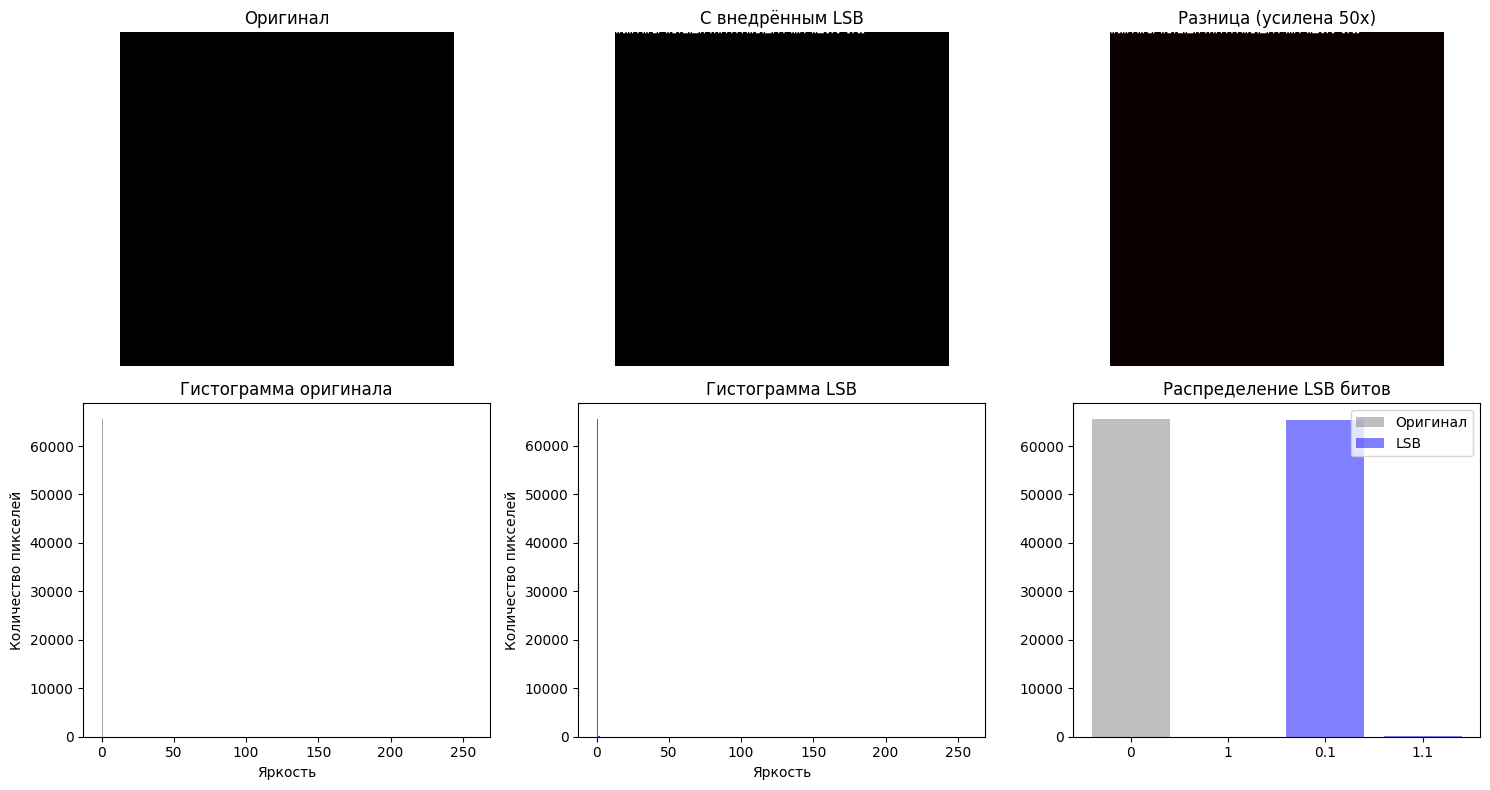


 Образец #64: gray_063.png

 Статистика изменений пикселей:
   Всего пикселей: 65,536
   Изменено пикселей: 144
   Процент изменений: 0.2197%
   Уникальные изменения: [0 1]

 Проверка извлечения сообщения:
   Ожидаемая длина: 24
   Извлечённая длина: 24
   Совпадение:  ДА

 Образец #128: gray_127.png

 Статистика изменений пикселей:
   Всего пикселей: 65,536
   Изменено пикселей: 144
   Процент изменений: 0.2197%
   Уникальные изменения: [0 1]

 Проверка извлечения сообщения:
   Ожидаемая длина: 24
   Извлечённая длина: 24
   Совпадение:  ДА

 Образец #192: gray_191.png

 Статистика изменений пикселей:
   Всего пикселей: 65,536
   Изменено пикселей: 144
   Процент изменений: 0.2197%
   Уникальные изменения: [0 1]

 Проверка извлечения сообщения:
   Ожидаемая длина: 24
   Извлечённая длина: 24
   Совпадение:  ДА

 Образец #256: gray_255.png

 Статистика изменений пикселей:
   Всего пикселей: 65,536
   Изменено пикселей: 144
   Процент изменений: 0.2197%
   Уникальные изменения: [0 1]



In [24]:
# Запуск полной проверки датасета

results = full_dataset_verification(INPUT_DIR, OUTPUT_DIR, SECRET_MESSAGE, num_samples=5)